# 이동평균과정 모델링

Start Date: July 03, 2026

일부 정상 시계열은 차분 후에도 자기상관관계가 있을 수 있음 (ex. 특정 패턴을 보임)
- 일부는 *이동평균 모델 (Moving Average)* **MA(q)**, *자기회귀모델 (Autoregressive Model)* **AR(p)**, *자기회귀이동평균 (Autoregressive Moving Average Model)* **ARMA(p, q)** 로 근사화 가능

# 4.1 이동평균과정 정의

이동평균 모델 (MA(q)): 
- **현잿값이 현재와 과거 오차에 선형적으로 비례한다.**
- 오차가 백색소음과 같이 상호 독립적 & 정규분포한다 가정
- q는 차수 (degree)
    - 현잿값에 영향을 미치는 과거 오차 항의 개수를 결정 (ex. q = 2인 경우 평균, 현재 오차 항 ($\epsilon_t$), 한 번의 시간 단계 이전의 오차 항($\theta_1  \epsilon_{t-1}$), 두 번의 시간 단계 이전의 오차 항 ($\theta_2  \epsilon_{t-2}$)에서 도출)
    - q가 클수록 더 많은 과거 오차 항이 현잿값에 영향을 미침. ==> 적절히 결정해야 적합한 모델을 구축할 수 있음

현잿값: 수열의 평균 $\mu$, 현재 오차항 $\epsilon_t$, 과거 오차 항 $\epsilon_{t-q}$의 선형 방정식으로 표현. </br>
현잿값에 과거 오차가 미치는 영향의 크기: $\theta_q$ 라는 계수 </br>
차수 q의 일반적인 이동평균과정: </br>
$y_t = \mu + \epsilon_t + \theta_1  \epsilon_{t-1} + \theta_2  \epsilon_{t-2} + ... + \theta_q  \epsilon_{t-q}$


적절한 q:
- "지연 q 이후 자기상관관계 계수가 갑자기 유의하지 않게 되는가?"에 yes라면, MA(q) 프로세스. 
- No라면, MA 프로세스가 아님.

## 4.1.1 이동평균과정의 차수 식별

In [1]:
import pandas as pd 
#data = widget_sales.csv
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/widget_sales.csv')
df.head()

#Unit: 1천 USD

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


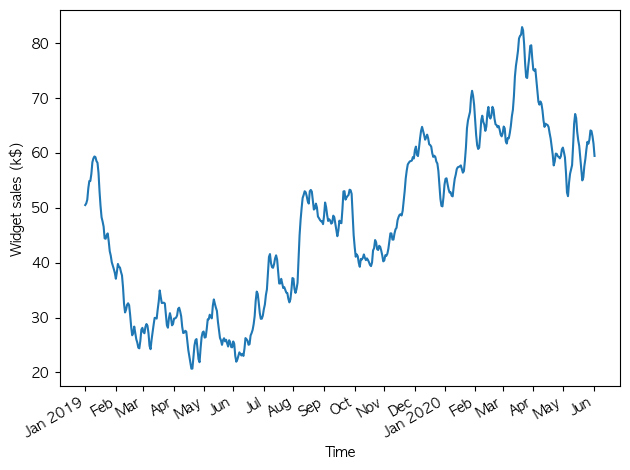

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()

ax.plot(df['widget_sales'])
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan 2019', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 
     'Jan 2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

# 그런데 여기서 xticks의 수치들은 어떻게 이렇게 accurate하게 내놓는거지??

fig.autofmt_xdate() #x axis tilted for legibility
plt.tight_layout()

비정상적인것 확인 </br>
Check with ADF

In [3]:
# Stationary Test

from statsmodels.tsa.stattools import adfuller

ADF_result = adfuller(df['widget_sales'])

print(f'ADF Stats: {ADF_result[0]}')
print(f'P-val: {ADF_result[1]}')

ADF Stats: -1.5121662069359016
P-val: 0.527484535227262


not a big ADF stats & p-val > 0.05 --> Not stationary --> So do 1st Differencing for stationary

In [4]:
import numpy as np

widget_sales_diff = np.diff(df['widget_sales'], n = 1)
len(widget_sales_diff)

499

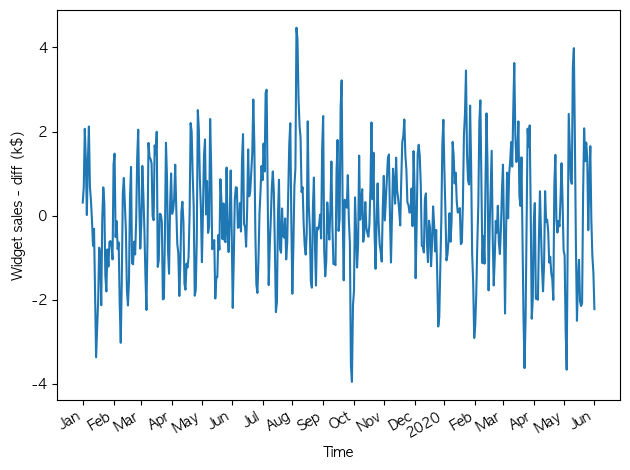

In [5]:
# Figure to check stationary
fig, ax = plt.subplots()

ax.plot(widget_sales_diff)
ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

Trend eliminated

ADF Test again for stationary check

In [6]:
ADF_result = adfuller(widget_sales_diff)

print(f'ADF Stats: {ADF_result[0]}')
print(f'P-val: {ADF_result[1]}')

ADF Stats: -10.57665778034196
P-val: 7.076922818587195e-19


Big negative num for ADF Stats, and much smaller than 0.05 for p-val

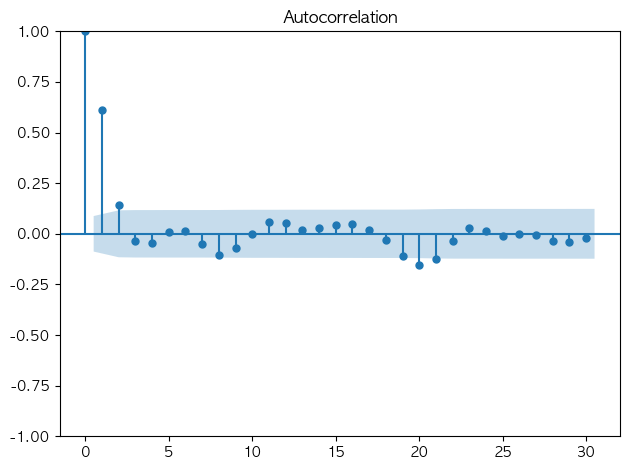

In [7]:
# Visualize ACF

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(widget_sales_diff, lags = 30) #lag = 30: approximately one month check; no mathematically significant meaning

plt.tight_layout()

Interpretation:
- until Lag2: 유의한 계수
- 그 이후는 유의하지 않음 (lag20 주변에서 유의한 계수 일부 보이나 3~20, 그리고 20~에서 유의하지 않으므로 이는 우연일 가능성이 높다) </br>
--> 차수 2의 정상적 이동평균 과정임. MA(2) 모델을 사용해 정상적 시계열 예측

특정 지연 이후 모든 계수가 유의하지 않다면, MA(q) 프로세스가 있다고 결론 내릴 수 있음.

# 4.2 이동평균과정 예측하기

q 식별 후, 모델을 훈련 데이터에 피팅하고 예측 시작 가능.

**주의:**
- MA는 수열이 정상적인 것을 가정하기에, **정상적 시계열**에 대해서만 예측을 수행해야 함.

정상적인 프로세스에 대한 예측을 얻은 후에는 예측을 역변환해야 함. ==> 차분 변환을 역으로 수행해야 함.

In [8]:
# 90% of data: train
# 10%: test

df_diff = pd.DataFrame({'widget_sales_diff': widget_sales_diff})

train = df_diff[:int(0.9*len(df_diff))] # 90% of front data falls into train
test = df_diff[int(0.9*len(df_diff)):]

print(len(train))
print(len(test))

449
50


Because we are using 1st differenced model, df_diff has total of 499 data.

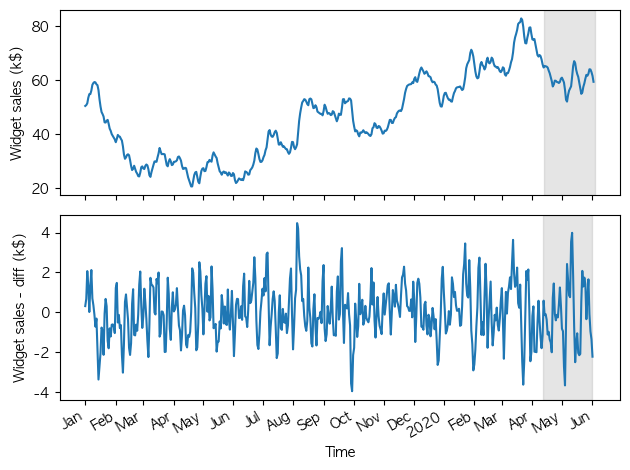

In [9]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

ax1.plot(df['widget_sales'])
ax1.set_xlabel('Time')
ax1.set_ylabel('Widget sales (k$)')
ax1.axvspan(450, 500, color='#808080', alpha=0.2)

ax2.plot(df_diff['widget_sales_diff'])
ax2.set_xlabel('Time')
ax2.set_ylabel('Widget sales - diff (k$)')
ax2.axvspan(449, 498, color='#808080', alpha=0.2)

plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409, 439, 468, 498], 
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

MA's characteristics on prediction availability:
- MA(q)는 한 번에 50단계 앞을 예측할 수 없음.
- 과거 오차 항에 선형적으로 의존하고, 이 항은 데이터 집합에서 관찰되지 않아 재귀적으로 추정해야 함.
    - 즉, 앞으로 q 단계까지만 예측 가능. (q 단계 이후의 미래 예측은 유의하지 않음)
    - 그 이후는 모델이 과거 오차항 없이 평균만 예측 (=베이스라인 모델과 동일하게 평균만 반환 --> 예측 실패)

### Rolling Forecast (롤링 예측)
- 2번의 시간 단계 이후 미래에 대해 단순히 평균으로 예측하지 않으려면, 50번의 예측을 할 때까지 반복해서 1번 혹은 2번의 시간 단계씩 예측하는 함수를 개발하고 해당 예측을 테스트 집합의 관찰된 값과 비교하도록.
    - 첫 번째 반복: 첫 449 단계에 대해 훈련 후, 450 & 451번째 시간 단계를 예측.
    - 두 번째 반복: 첫 451 단계에 대해 훈련 후, 452 & 453번째 시간 단계를 예측.
    - 마지막으로 498번째와 499번째 시간 단계를 예측할 때까지 과정을 반복. (훈련 세트를 2개씩 늘려가며 반복.)

왜 2개씩? --> MA(2) 였으니까.

Comparison: MA(2) vs. Baseline(Past Average & Recent)

전체 테스트 집합에 대한 예측을 완료할 때까지 지정한 기간과 지정한 시간 단계 횟수 동안 반복적으로 모델을 피팅하고 예측을 수행하는 함수가 필요.

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def rolling_forecast(df: pd.DataFrame, train_len: int, horizon: int, 
                     window: int, method: str) -> list:
    #window: 한 번에 예측할 시간 단계 횟수 지정 (MA(2)일 경우 window = 2)
    
    total_len = train_len + horizon

    if method == 'mean': # 과거 평균 기반
        pred_mean = []

        for i in range(train_len, total_len, window):
            mean = np.mean(df[:i].values)
            pred_mean.extend(mean for _ in range(window))

        return pred_mean

    elif method == 'last': # 최근값 기반
        pred_last_value = []

        for i in range(train_len, total_len, window):
            last_value = df[:i].iloc[-1].values[0]
            pred_last_value.extend(last_value for _ in range(window))
        
        return pred_last_value
    
    elif method == 'MA':
        pred_MA = []

        for i in range(train_len, total_len, window):
            model = SARIMAX(df[:i], order = (0,0,2)) #(0,0,2): MA(q)의 순서
            res = model.fit(disp = False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:] #predicted_mean을 토해 예측한 실젯값을 추출
            pred_MA.extend(oos_pred)

        return pred_MA

In [11]:
# test 집합에서 실제 관측값을 복사.
pred_df = test.copy() 

TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

pred_mean = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'last')
pred_MA = rolling_forecast(df_diff, TRAIN_LEN, HORIZON, WINDOW, 'MA')

pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_MA'] = pred_MA

pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_MA
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


**REMEMBER:**
- We are still using differenced dataset.

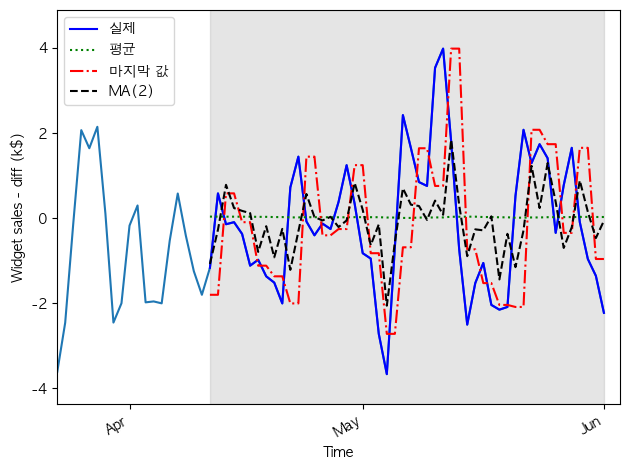

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots()

ax.plot(df_diff['widget_sales_diff'])
ax.plot(pred_df['widget_sales_diff'], 'b-', label='실제')
ax.plot(pred_df['pred_mean'], 'g:', label='평균')
ax.plot(pred_df['pred_last_value'], 'r-.', label='마지막 값')
ax.plot(pred_df['pred_MA'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales - diff (k$)')

ax.axvspan(449, 498, color='#808080', alpha=0.2)

ax.set_xlim(430, 500)

plt.xticks(
    [439, 468, 498], 
    ['Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

Interpretation:
- Past Average: 거의 직선 --> 프로세스가 정상적이므로 시간이 지나도 과거 평균은 변화가 없어야 함.
</br>

Next: Evaluate Model Performance (MSE)

In [13]:
from sklearn.metrics import mean_squared_error

mse_mean = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean'])
mse_last = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value'])
mse_MA = mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_MA'])

print(mse_mean, mse_last, mse_MA)

2.5606299456880532 3.2494260812249225 1.9481714497747022


MSE가 가장 낮음 --> MSE 시각화

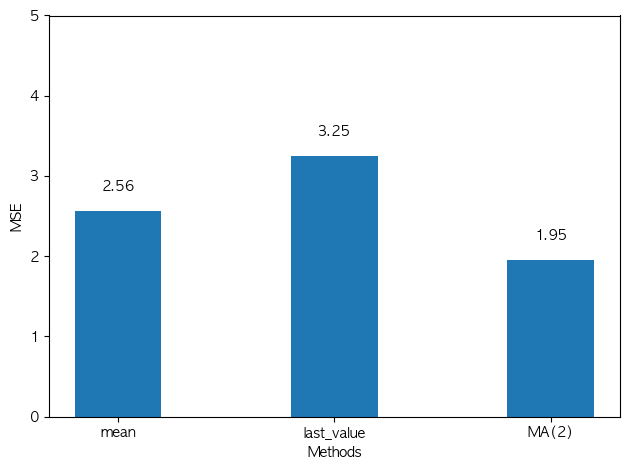

In [14]:
fig, ax = plt.subplots()

x = ['mean', 'last_value', 'MA(2)']
y = [mse_mean, mse_last, mse_MA]

ax.bar(x, y, width=0.4)
ax.set_xlabel('Methods')
ax.set_ylabel('MSE')
ax.set_ylim(0, 5)

for index, value in enumerate(y):
    plt.text(x=index, y=value+0.25, s=str(round(value, 2)), ha='center')

plt.tight_layout()

예측 결과를 역변환하여 데이터 집합의 변환하지 않은 원래 규모로 되돌려야 함. </br>
1차 차분을 역변환하기 위해서는:
- 첫 번째 차분 값인 $y'_{1}$에 초깃값인 $y_0$을 더해야 함. </br>
$y_1 = y_0+y'_1 = y_0 + y_1 - y_0 = y_1$ </br>

- 차분된 값들을 누적으로 합계하여 $y_2$를 구할 수 있음. </br>
$y_2 = y_0 + y'_1 + y'_2 = y_0 + y_1 - y_0 + y_2 - y_1 = (y_0-y_0) + (y_1 - y_1) + y_2 = y_2$

In [ ]:
df['pred_widget_sales'] = pd.Series() #예측값을 저장할 빈 열을 초기화

#예측값 역변환해 데이터 집합의 원래 규모로 되돌림
df['pred_widget_sales'][450:] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()

df.tail()

/var/folders/3z/5gfy93qs7vz0g17fs_bg32xr0000gn/T/ipykernel_4228/1671265230.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['pred_widget_sales'][450:] = df['widget_sales'].iloc[450] + pred_df['pred_MA'].cumsum()
/var/folders/3z/5gfy93q

,widget_sales,pred_widget_sales
495,64.087371,60.335201
496,63.992081,61.218392
497,63.029894,61.365771
498,61.671797,60.895973
499,59.443839,60.832373


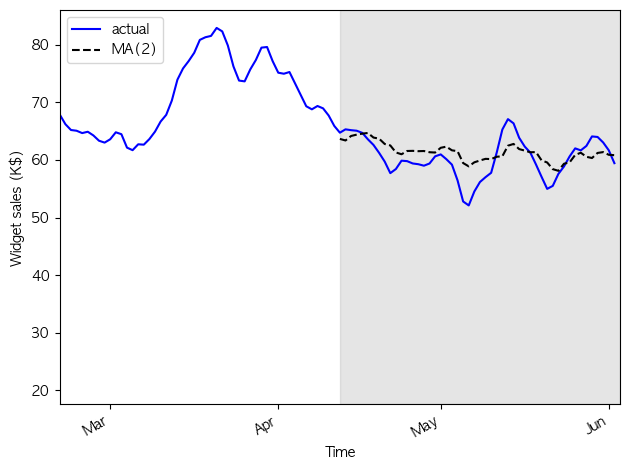

In [16]:
fig, ax = plt.subplots()

ax.plot(df['widget_sales'], 'b-', label='actual')
ax.plot(df['pred_widget_sales'], 'k--', label='MA(2)')

ax.legend(loc=2)

ax.set_xlabel('Time')
ax.set_ylabel('Widget sales (K$)')

ax.axvspan(450, 500, color='#808080', alpha=0.2)

ax.set_xlim(400, 500)

plt.xticks(
    [409, 439, 468, 498], 
    ['Mar', 'Apr', 'May', 'Jun'])

fig.autofmt_xdate()
plt.tight_layout()

Interpretation:
- 예측 곡선이 일반적인 추세는 따르나, 최저/최고점을 예측하지는 못함.

### 원본 집합에 대한 MSE

차분된 값은 비즈니스적 의미가 없어 보고하지 않기에, 데이터의 원래 규모로 값과 오차를 보고해야 함.

In [20]:
# Use Absolute Difference (~= MAE)

from sklearn.metrics import mean_absolute_error

mae_MA_undiff = mean_absolute_error(df['widget_sales'].iloc[450:],
                                    df['pred_widget_sales'].iloc[450:])

print(mae_MA_undiff)

2.324470924331371


Interpretation:
- 데이터의 단위는 $1,000 단위이기에, 실제 해석은 **"평균적으로 2,320달러 정도 벗어났다."**